In [ ]:
import pandas as pd

file_path = r"C:\Users\Lakshay\Desktop\Deep-Learning-\Practice Day 02\Churn_Modelling.csv"

df = pd.read_csv(file_path)

print(df.head())

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [ ]:
df = pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.duplicated().value_counts()

False    10000
Name: count, dtype: int64

In [ ]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [ ]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [ ]:
df = pd.get_dummies(df,columns=['Gender', 'Geography'],drop_first=True,dtype=int)

In [ ]:
df.sample(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Gender_Male,Geography_Germany,Geography_Spain
7219,581,54,4,89299.81,1,0,0,5558.47,1,1,0,0
3158,643,31,3,167949.48,1,1,0,143162.34,0,0,0,0
2894,531,31,3,0.00,1,1,1,42589.33,0,1,0,0
1527,661,35,8,124098.54,1,1,0,86678.48,0,1,1,0
9346,716,41,9,0.00,1,1,1,113267.48,0,1,0,0


In [ ]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()

In [ ]:
X = df.drop(columns=['Exited'])
y = df['Exited']

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.33, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled

array([[ 1.67588802, -0.94183739,  0.00934296, ..., -1.10022343,
         1.74875572, -0.57987798],
       [ 0.30320673, -0.17987213,  1.04687659, ...,  0.9089063 ,
         1.74875572, -0.57987798],
       [-0.10235819,  0.96307575, -0.33650158, ...,  0.9089063 ,
         1.74875572, -0.57987798],
       ...,
       [ 0.86475817, -0.08462648, -1.37403521, ..., -1.10022343,
        -0.57183516, -0.57987798],
       [ 0.15761932,  0.39160181,  1.04687659, ...,  0.9089063 ,
        -0.57183516, -0.57987798],
       [ 0.46959234,  1.15356706, -1.37403521, ...,  0.9089063 ,
         1.74875572, -0.57987798]])

In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(20, activation='relu',input_dim=11),
    Dense(11, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [ ]:
history = model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7549 - loss: 0.5332 - val_accuracy: 0.8157 - val_loss: 0.4483
Epoch 2/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8071 - loss: 0.4475 - val_accuracy: 0.8216 - val_loss: 0.4217
Epoch 3/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8168 - loss: 0.4308 - val_accuracy: 0.8284 - val_loss: 0.4144
Epoch 4/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8229 - loss: 0.4214 - val_accuracy: 0.8299 - val_loss: 0.4108
Epoch 5/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8291 - loss: 0.4130 - val_accuracy: 0.8351 - val_loss: 0.4028
Epoch 6/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8325 - loss: 0.4036 - val_accuracy: 0.8388 - val_loss: 0.3933
Epoch 7/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8358 - loss: 0.3915 - val_accuracy: 0.8373 - val_loss: 0.3832
Epoch 8/100
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8453 - loss: 0.3788 - val_accu

In [ ]:
y_log = model.predict(X_test_scaled)

104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
y_pred = np.where(y_log>0.5,1,0)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)

In [ ]:
accuracy

0.8651515151515151

In [ ]:
import numpy as np

best_epoch = np.argmin(history.history['val_loss'])

print("Best epoch:", best_epoch + 1)
print("Best validation loss:", history.history['val_loss'][best_epoch])
print("Validation accuracy at that epoch:",
      history.history['val_accuracy'][best_epoch])

Best epoch: 35
Best validation loss: 0.34512850642204285
Validation accuracy at that epoch: 0.85447758436203


In [ ]:
import matplotlib.pyplot as plt

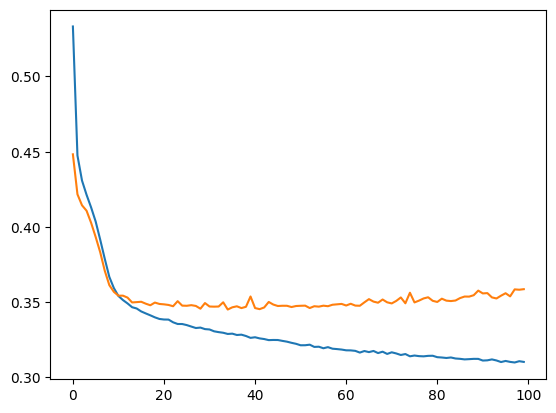

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

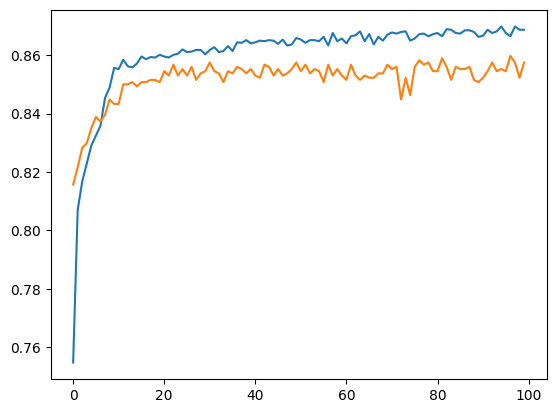

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])